# RQ8 — Temporal Localisation of the Discriminative Event

## Research question

> Where within one commanded one-digit movement does the true-gate acoustic difference occur?

RQ7 showed that retaining absolute acoustic information improves held-out-password ranking under the fixed LOPO ablation. That still does not establish *what physical event* the model is using. RQ8 therefore asks whether the discriminative signal is distributed across the movement or concentrated around a repeatable release-like event.

The analysis is deliberately split into **discovery**, **frozen confirmation**, and **supporting evidence**.

### Primary temporal-localisation experiment

Historical W1/W2 data are aligned to `SCAN_END`.

A **25 ms** analysis window is moved in **5 ms** steps over the final **140 ms** of the Current movement.

For each 10-candidate decision:

1. a log-Mel spectrum is calculated for every candidate in the same time window;
2. the per-Mel median across the 10 candidates is used as the within-scan baseline;
3. each candidate receives a scalar residual log-Mel score;
4. the scan-level outcome is

\[
\Delta = score_{true} - median(score_{false})
\]

A positive \(\Delta\) means that the true-gate candidate is acoustically elevated relative to the other nine candidates at that time.

### Confirmatory window

The historical RQ8 work identified a W2 window at:

**`SCAN_END −60 ms → −35 ms`**

This window is treated as frozen in the reconstruction. It is evaluated on password **2748** without changing the timing.

This is important: the 2748 data do not choose their own best window.

### Negative and cross-wheel evidence

- W1 is analysed with the same sliding-window procedure as a negative/control wheel.
- The controlled RQ1 temporal-envelope result for W1/W2/W4 is reused as independent supporting evidence for wheel-dependent timing.
- Earlier exploratory W3/W4 work is preserved in the audit table rather than mixed into the confirmatory test.

### Final engineering decision

A dedicated end-window branch was later tested in MAIN v7 model development. Its selected contribution was **0%**. Final MAIN v7 therefore uses the full movement rather than assuming one universal end-localised event.

The purpose of RQ8 is therefore not to prove that the end of every wheel is sufficient. It is to determine whether a local release-like event exists, whether it transfers, and whether its timing is universal enough to justify a dedicated model branch.

## 1. Mount Drive and stage the historical raw data locally

In [40]:
from google.colab import drive
from pathlib import Path

import os
import shutil
import zipfile
import json

import numpy as np
import pandas as pd
from IPython.display import display


def ensure_drive():
    mount_point = Path("/content/drive")

    try:
        drive.mount(
            str(mount_point),
            force_remount=False,
        )

        list(
            (
                mount_point
                / "MyDrive"
            ).iterdir()
        )

    except OSError:
        print(
            "Drive mount is stale; reconnecting..."
        )

        os.system(
            "fusermount -u /content/drive "
            "2>/dev/null || true"
        )

        os.system(
            "umount -l /content/drive "
            "2>/dev/null || true"
        )

        drive.mount(
            str(mount_point),
            force_remount=True,
        )

        list(
            (
                mount_point
                / "MyDrive"
            ).iterdir()
        )

    return mount_point


DRIVE_MOUNT = ensure_drive()
MYDRIVE = DRIVE_MOUNT / "MyDrive"

PROJECT_ROOT = (
    MYDRIVE
    / "Padlock_Reproduction_v1"
)

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT
    / "Padlock_Reproduction_v1"
    / "results",
]

RESULTS_ROOT = next(
    (
        p
        for p in results_candidates
        if p.exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate Padlock_Reproduction_v1/results."
    )

RESULT_DIR = (
    RESULTS_ROOT
    / "08_RQ8_Temporal_Localisation"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LOCAL_STAGE = Path(
    "/content/rq8_stage"
)

LOCAL_STAGE.mkdir(
    parents=True,
    exist_ok=True,
)

DATASET_ROOT = (
    MYDRIVE
    / "dataset"
)

HIST_ROOT_CANDIDATES = [
    DATASET_ROOT
    / "raw"
    / "historical_data",
    DATASET_ROOT
    / "historical_data",
    DATASET_ROOT,
]


def locate_source(stem):
    candidates = []

    for root in HIST_ROOT_CANDIDATES:
        candidates.extend([
            root / f"{stem}.zip",
            root / stem,
        ])

    for path in candidates:
        try:
            if path.exists():
                return path
        except OSError:
            ensure_drive()

            if path.exists():
                return path

    raise FileNotFoundError(
        (
            f"Could not find {stem} as either a ZIP "
            "or folder under dataset/raw/historical_data, "
            "dataset/historical_data, or dataset."
        )
    )


def stage_source(stem):
    source = locate_source(
        stem
    )

    local_root = (
        LOCAL_STAGE
        / stem
    )

    run_dirs = sorted(
        [
            p
            for p in local_root.rglob("run_*")
            if p.is_dir()
        ]
    ) if local_root.exists() else []

    if run_dirs:
        return local_root

    if local_root.exists():
        shutil.rmtree(
            local_root
        )

    local_root.mkdir(
        parents=True
    )

    if source.is_file():
        local_zip = (
            LOCAL_STAGE
            / f"{stem}.zip"
        )

        shutil.copy2(
            source,
            local_zip,
        )

        with zipfile.ZipFile(
            local_zip,
            "r",
        ) as z:
            z.extractall(
                local_root
            )

    else:
        # Folder fallback when no raw ZIP is present.
        # Copy once to local disk so the analysis does not repeatedly
        # read thousands of small files through the Drive FUSE mount.
        shutil.rmtree(
            local_root
        )

        shutil.copytree(
            source,
            local_root,
        )

    run_dirs = sorted(
        [
            p
            for p in local_root.rglob("run_*")
            if p.is_dir()
        ]
    )

    if not run_dirs:
        raise RuntimeError(
            f"{stem}: no run_* folders found after staging."
        )

    print(
        stem,
        "runs staged:",
        len(run_dirs),
    )

    return local_root


SOURCE_ROOTS = {
    "W1_1111": stage_source(
        "digit_W1_data"
    ),
    "W2_1111": stage_source(
        "digit_W2_data"
    ),
    "W2_2748": stage_source(
        "code_2748_test_data"
    ),
}

print(
    "RQ8 results:",
    RESULT_DIR,
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RQ8 results: /content/drive/MyDrive/Padlock_Reproduction_v1/results/08_RQ8_Temporal_Localisation


## 2. Reconstruct Current-movement decisions

In [41]:
def build_manifest(
    label,
    source_root,
    wheel_filter,
):
    rows = []

    run_dirs = sorted(
        [
            p
            for p in source_root.rglob("run_*")
            if p.is_dir()
        ],
        key=lambda p: int(
            p.name.split("_")[-1]
        ),
    )

    for run_dir in run_dirs:
        metadata_path = (
            run_dir
            / "metadata.json"
        )

        if not metadata_path.exists():
            continue

        with open(
            metadata_path,
            "r",
            encoding="utf-8-sig",
        ) as f:
            meta = json.load(
                f
            )

        run = meta[
            "run"
        ]

        wheel = int(
            run[
                "wheel_index"
            ]
        )

        if wheel != wheel_filter:
            continue

        rows.append({
            "dataset": label,
            "run_id": run[
                "run_id"
            ],
            "run_num": int(
                run[
                    "run_id"
                ].split("_")[-1]
            ),
            "wheel": wheel,
            "profile_id": run.get(
                "profile_id",
                "",
            ),
            "decision_id": run.get(
                "decision_id",
                "",
            ),
            "repeat_id": run.get(
                "decision_repeat_id",
                "",
            ),
            "candidate_index": int(
                run.get(
                    "decision_candidate_index",
                    0,
                )
            ),
            "target_digit": int(
                run.get(
                    "decision_target_digit",
                    -1,
                )
            ),
            "is_true_gate": int(
                run.get(
                    "decision_is_true_gate_movement",
                    0,
                )
            ),
            "run_path": str(
                run_dir
            ),
        })


    manifest = (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "run_num"
        )
        .reset_index(
            drop=True
        )
    )

    audit = (
        manifest
        .groupby(
            [
                "decision_id",
                "repeat_id",
            ]
        )
        .agg(
            n_candidates=(
                "run_id",
                "size",
            ),
            n_true=(
                "is_true_gate",
                "sum",
            ),
        )
        .reset_index()
    )

    valid_keys = audit.loc[
        (
            audit[
                "n_candidates"
            ]
            == 10
        )
        &
        (
            audit[
                "n_true"
            ]
            == 1
        ),
        [
            "decision_id",
            "repeat_id",
        ],
    ]

    manifest = manifest.merge(
        valid_keys,
        on=[
            "decision_id",
            "repeat_id",
        ],
        how="inner",
    )

    print(
        label,
        "decisions:",
        manifest.groupby(
            [
                "decision_id",
                "repeat_id",
            ]
        ).ngroups,
    )

    return manifest


manifest_w1 = build_manifest(
    "W1_1111",
    SOURCE_ROOTS[
        "W1_1111"
    ],
    wheel_filter=1,
)

manifest_w2 = build_manifest(
    "W2_1111",
    SOURCE_ROOTS[
        "W2_1111"
    ],
    wheel_filter=2,
)

manifest_2748 = build_manifest(
    "W2_2748",
    SOURCE_ROOTS[
        "W2_2748"
    ],
    wheel_filter=2,
)

manifest = pd.concat(
    [
        manifest_w1,
        manifest_w2,
        manifest_2748,
    ],
    ignore_index=True,
)

manifest.to_csv(
    RESULT_DIR
    / "RQ8_manifest.csv",
    index=False,
)

display(
    manifest.groupby(
        "dataset"
    ).agg(
        runs=(
            "run_id",
            "size",
        ),
        decisions=(
            "decision_id",
            "nunique",
        ),
    )
)

W1_1111 decisions: 84
W2_1111 decisions: 96
W2_2748 decisions: 18


,runs,decisions
dataset,,
W1_1111,840,42
W2_1111,960,48
W2_2748,180,9


## 3. Residual log-Mel score

The historical RQ8 method is reconstructed as a within-decision spectral residual.

For one fixed time window:

- each candidate is converted to a 24-band log-Mel spectrum;
- the median spectrum across all 10 candidates is subtracted;
- the remaining residual is averaged across Mel bands to give one candidate score.

This deliberately asks whether one candidate contains a local energy/spectral excess relative to the other nine candidates recorded under the same scan-level state.

The metric is not intended as a final classifier. It is a localisation statistic.

In [42]:
import soundfile as sf

from scipy.stats import (
    rankdata,
    wilcoxon,
)

from statsmodels.stats.multitest import (
    multipletests,
)


WINDOW_MS = 25
STRIDE_MS = 5
LOOKBACK_MS = 140

WINDOW_STARTS_MS = np.arange(
    -LOOKBACK_MS,
    -WINDOW_MS + 1,
    STRIDE_MS,
    dtype=float,
)

LOCKED_START_MS = -60.0
LOCKED_END_MS = -35.0

N_MELS = 24
FMIN_HZ = 300.0
FMAX_HZ = 12000.0
N_FFT = 2048

EPS = 1e-12
_mel_cache = {}


def hz_to_mel(freq_hz):
    return (
        2595.0
        * np.log10(
            1.0
            + freq_hz
            / 700.0
        )
    )


def mel_to_hz(mel):
    return (
        700.0
        * (
            10.0
            ** (
                mel
                / 2595.0
            )
            - 1.0
        )
    )


def mel_filterbank(
    sr,
    n_fft=N_FFT,
    n_mels=N_MELS,
    fmin=FMIN_HZ,
    fmax=FMAX_HZ,
):
    key = (
        int(sr),
        int(n_fft),
        int(n_mels),
        float(fmin),
        float(fmax),
    )

    if key in _mel_cache:
        return _mel_cache[
            key
        ]

    fmax = min(
        fmax,
        sr / 2 - 1.0,
    )

    mel_edges = np.linspace(
        hz_to_mel(
            fmin
        ),
        hz_to_mel(
            fmax
        ),
        n_mels + 2,
    )

    hz_edges = mel_to_hz(
        mel_edges
    )

    freqs = np.fft.rfftfreq(
        n_fft,
        d=1.0 / sr,
    )

    fb = np.zeros(
        (
            n_mels,
            len(freqs),
        ),
        dtype=float,
    )

    for m in range(
        n_mels
    ):
        left = hz_edges[
            m
        ]
        centre = hz_edges[
            m + 1
        ]
        right = hz_edges[
            m + 2
        ]

        rising = (
            (
                freqs
                - left
            )
            /
            max(
                centre
                - left,
                EPS,
            )
        )

        falling = (
            (
                right
                - freqs
            )
            /
            max(
                right
                - centre,
                EPS,
            )
        )

        fb[
            m
        ] = np.maximum(
            0.0,
            np.minimum(
                rising,
                falling,
            ),
        )

    _mel_cache[
        key
    ] = fb

    return fb


def log_mel_vector(
    x,
    sr,
):
    x = np.asarray(
        x,
        dtype=np.float64,
    )

    if len(
        x
    ) < 32:
        raise ValueError(
            "Window too short."
        )

    x = (
        x
        - np.mean(
            x
        )
    )

    window = np.hanning(
        len(x)
    )

    spectrum = np.fft.rfft(
        x
        * window,
        n=N_FFT,
    )

    power = (
        np.abs(
            spectrum
        )
        ** 2
    )

    fb = mel_filterbank(
        sr
    )

    mel_power = (
        fb
        @ power
    )

    return (
        10.0
        * np.log10(
            mel_power
            + EPS
        )
    )


def load_run_audio(
    run_path,
):
    run_path = Path(
        run_path
    )

    events = pd.read_csv(
        run_path
        / "events.csv"
    )

    end_rows = events[
        events[
            "event"
        ]
        == "SCAN_END"
    ]

    if len(
        end_rows
    ) != 1:
        raise RuntimeError(
            f"{run_path.name}: invalid SCAN_END event."
        )

    scan_end = int(
        end_rows.iloc[
            0
        ][
            "aligned_sample_index"
        ]
    )

    audio, sr = sf.read(
        run_path
        / "audio.wav",
        dtype="float32",
    )

    if audio.ndim == 2:
        # Historical convention: channel 1 / first column is the target/contact channel.
        audio = audio[
            :,
            0,
        ]

    return (
        audio,
        int(sr),
        scan_end,
    )


def window_segment(
    audio,
    sr,
    scan_end,
    start_ms,
    end_ms,
):
    start = int(
        round(
            scan_end
            + start_ms
            * sr
            / 1000.0
        )
    )

    end = int(
        round(
            scan_end
            + end_ms
            * sr
            / 1000.0
        )
    )

    if (
        start < 0
        or end > len(
            audio
        )
        or end <= start
    ):
        raise RuntimeError(
            (
                "Invalid window:",
                start_ms,
                end_ms,
                start,
                end,
                len(audio),
            )
        )

    return audio[
        start:end
    ]

## 4. Sliding-window localisation on W1 and W2 historical data

In [43]:
def analyse_temporal_windows(
    data,
    window_starts_ms,
):
    rows = []

    groups = list(
        data.groupby(
            [
                "decision_id",
                "repeat_id",
            ],
            sort=False,
        )
    )

    for group_number, (
        (
            decision_id,
            repeat_id,
        ),
        group,
    ) in enumerate(
        groups,
        start=1,
    ):
        group = (
            group
            .sort_values(
                "candidate_index"
            )
            .reset_index(
                drop=True
            )
        )

        if (
            len(
                group
            )
            != 10
            or group[
                "is_true_gate"
            ].sum()
            != 1
        ):
            continue

        loaded = []

        for row in group.itertuples(
            index=False
        ):
            loaded.append(
                load_run_audio(
                    row.run_path
                )
            )

        for start_ms in window_starts_ms:
            end_ms = (
                start_ms
                + WINDOW_MS
            )

            log_mels = []

            for (
                audio,
                sr,
                scan_end,
            ) in loaded:
                segment = window_segment(
                    audio,
                    sr,
                    scan_end,
                    start_ms,
                    end_ms,
                )

                log_mels.append(
                    log_mel_vector(
                        segment,
                        sr,
                    )
                )

            log_mels = np.vstack(
                log_mels
            )

            baseline = np.median(
                log_mels,
                axis=0,
            )

            residual = (
                log_mels
                - baseline
            )

            scores = residual.mean(
                axis=1
            )

            truth = (
                group[
                    "is_true_gate"
                ].to_numpy(
                    dtype=int
                )
                == 1
            )

            true_score = float(
                scores[
                    truth
                ][0]
            )

            false_scores = scores[
                ~truth
            ]

            contrast = (
                true_score
                - float(
                    np.median(
                        false_scores
                    )
                )
            )

            ranks = rankdata(
                -scores,
                method="average",
            )

            true_rank = float(
                ranks[
                    truth
                ][0]
            )

            rows.append({
                "dataset": group[
                    "dataset"
                ].iloc[0],
                "decision_id": decision_id,
                "repeat_id": repeat_id,
                "window_start_ms": float(
                    start_ms
                ),
                "window_end_ms": float(
                    end_ms
                ),
                "window_centre_ms": float(
                    (
                        start_ms
                        + end_ms
                    )
                    / 2.0
                ),
                "true_score_db": true_score,
                "median_false_score_db": float(
                    np.median(
                        false_scores
                    )
                ),
                "contrast_db": float(
                    contrast
                ),
                "true_rank": true_rank,
                "top1": int(
                    true_rank <= 1
                ),
                "top2": int(
                    true_rank <= 2
                ),
                "top3": int(
                    true_rank <= 3
                ),
            })

        if (
            group_number
            % 10
            == 0
        ):
            print(
                group[
                    "dataset"
                ].iloc[0],
                f"{group_number}/{len(groups)} decisions",
            )

    return pd.DataFrame(
        rows
    )


W1_SCORE_PATH = (
    RESULT_DIR
    / "RQ8_W1_1111_temporal_scores.csv"
)

W2_SCORE_PATH = (
    RESULT_DIR
    / "RQ8_W2_1111_temporal_scores.csv"
)


if W1_SCORE_PATH.exists():
    scores_w1 = pd.read_csv(
        W1_SCORE_PATH
    )
else:
    scores_w1 = analyse_temporal_windows(
        manifest_w1,
        WINDOW_STARTS_MS,
    )

    scores_w1.to_csv(
        W1_SCORE_PATH,
        index=False,
    )


if W2_SCORE_PATH.exists():
    scores_w2 = pd.read_csv(
        W2_SCORE_PATH
    )
else:
    scores_w2 = analyse_temporal_windows(
        manifest_w2,
        WINDOW_STARTS_MS,
    )

    scores_w2.to_csv(
        W2_SCORE_PATH,
        index=False,
    )


print(
    "W1 score rows:",
    len(
        scores_w1
    ),
)

print(
    "W2 score rows:",
    len(
        scores_w2
    ),
)

W1 score rows: 2016
W2 score rows: 2304


In [44]:
def safe_wilcoxon_greater(
    values,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    if np.allclose(
        values,
        0,
    ):
        return (
            0.0,
            1.0,
        )

    stat, p_value = wilcoxon(
        values,
        alternative="greater",
        zero_method="wilcox",
        method="auto",
    )

    return (
        float(
            stat
        ),
        float(
            p_value
        ),
    )


def bootstrap_median_ci(
    values,
    seed,
    n_boot=5000,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    rng = np.random.default_rng(
        seed
    )

    index = rng.integers(
        0,
        len(
            values
        ),
        size=(
            n_boot,
            len(
                values
            ),
        ),
    )

    medians = np.median(
        values[
            index
        ],
        axis=1,
    )

    return np.quantile(
        medians,
        [
            0.025,
            0.975,
        ],
    )


def summarise_windows(
    scores,
    seed_base,
):
    rows = []

    for i, (
        start_ms,
        group,
    ) in enumerate(
        scores.groupby(
            "window_start_ms",
            sort=True,
        )
    ):
        contrasts = group[
            "contrast_db"
        ].to_numpy(
            dtype=float
        )

        stat, p_value = (
            safe_wilcoxon_greater(
                contrasts
            )
        )

        ci_low, ci_high = (
            bootstrap_median_ci(
                contrasts,
                seed=(
                    seed_base
                    + i
                ),
            )
        )

        std = np.std(
            contrasts,
            ddof=1,
        )

        effect_d = (
            np.mean(
                contrasts
            )
            / std
            if std > 1e-12
            else np.nan
        )

        rows.append({
            "dataset": group[
                "dataset"
            ].iloc[0],
            "window_start_ms": float(
                start_ms
            ),
            "window_end_ms": float(
                group[
                    "window_end_ms"
                ].iloc[0]
            ),
            "window_centre_ms": float(
                group[
                    "window_centre_ms"
                ].iloc[0]
            ),
            "n_decisions": len(
                contrasts
            ),
            "median_contrast_db": float(
                np.median(
                    contrasts
                )
            ),
            "mean_contrast_db": float(
                np.mean(
                    contrasts
                )
            ),
            "median_ci_low": float(
                ci_low
            ),
            "median_ci_high": float(
                ci_high
            ),
            "positive_n": int(
                (
                    contrasts
                    > 0
                ).sum()
            ),
            "positive_rate": float(
                np.mean(
                    contrasts
                    > 0
                )
            ),
            "top1": float(
                group[
                    "top1"
                ].mean()
            ),
            "top2": float(
                group[
                    "top2"
                ].mean()
            ),
            "top3": float(
                group[
                    "top3"
                ].mean()
            ),
            "mean_true_rank": float(
                group[
                    "true_rank"
                ].mean()
            ),
            "effect_d": float(
                effect_d
            ),
            "wilcoxon_statistic": stat,
            "p_raw": p_value,
        })

    summary = pd.DataFrame(
        rows
    )

    summary[
        "p_holm"
    ] = multipletests(
        summary[
            "p_raw"
        ],
        method="holm",
    )[1]

    return summary


summary_w1 = summarise_windows(
    scores_w1,
    seed_base=20260819,
)

summary_w2 = summarise_windows(
    scores_w2,
    seed_base=20260919,
)

discovery_summary = pd.concat(
    [
        summary_w1,
        summary_w2,
    ],
    ignore_index=True,
)

discovery_summary.to_csv(
    RESULT_DIR
    / "RQ8_discovery_window_summary.csv",
    index=False,
)

display(
    discovery_summary.loc[
        discovery_summary[
            "window_start_ms"
        ]
        == LOCKED_START_MS
    ].round(
        4
    )
)

,dataset,window_start_ms,window_end_ms,window_centre_ms,n_decisions,median_contrast_db,mean_contrast_db,median_ci_low,median_ci_high,positive_n,positive_rate,top1,top2,top3,mean_true_rank,effect_d,wilcoxon_statistic,p_raw,p_holm
16,W1_1111,-60.0,-35.0,-47.5,84,0.3048,2.0717,-0.4707,1.0982,43,0.5119,0.1429,0.2262,0.3810,5.2381,0.3226,2211.0,0.0287,0.4094
40,W2_1111,-60.0,-35.0,-47.5,96,1.4337,6.2141,0.6082,3.0235,68,0.7083,0.1771,0.3438,0.4583,4.5833,0.5246,3560.0,0.0000,0.0001


## 5. Frozen W2 window on password 2748

Only the pre-specified `−60 → −35 ms` W2 window is evaluated here. The 2748 data are not scanned to choose a new best timing.

In [45]:
W2_2748_SCORE_PATH = (
    RESULT_DIR
    / "RQ8_W2_2748_locked_window_scores.csv"
)

if W2_2748_SCORE_PATH.exists():
    scores_2748 = pd.read_csv(
        W2_2748_SCORE_PATH
    )
else:
    scores_2748 = analyse_temporal_windows(
        manifest_2748,
        np.array(
            [
                LOCKED_START_MS
            ],
            dtype=float,
        ),
    )

    scores_2748.to_csv(
        W2_2748_SCORE_PATH,
        index=False,
    )


def locked_window_result(
    scores,
):
    contrasts = scores[
        "contrast_db"
    ].to_numpy(
        dtype=float
    )

    stat, p_value = (
        safe_wilcoxon_greater(
            contrasts
        )
    )

    std = np.std(
        contrasts,
        ddof=1,
    )

    effect_d = (
        np.mean(
            contrasts
        )
        / std
        if std > 1e-12
        else np.nan
    )

    return {
        "dataset": scores[
            "dataset"
        ].iloc[0],
        "window_start_ms": float(
            scores[
                "window_start_ms"
            ].iloc[0]
        ),
        "window_end_ms": float(
            scores[
                "window_end_ms"
            ].iloc[0]
        ),
        "n_decisions": len(
            scores
        ),
        "median_contrast_db": float(
            np.median(
                contrasts
            )
        ),
        "mean_contrast_db": float(
            np.mean(
                contrasts
            )
        ),
        "positive_n": int(
            (
                contrasts
                > 0
            ).sum()
        ),
        "positive_rate": float(
            np.mean(
                contrasts
                > 0
            )
        ),
        "top1": float(
            scores[
                "top1"
            ].mean()
        ),
        "top2": float(
            scores[
                "top2"
            ].mean()
        ),
        "top3": float(
            scores[
                "top3"
            ].mean()
        ),
        "mean_true_rank": float(
            scores[
                "true_rank"
            ].mean()
        ),
        "effect_d": float(
            effect_d
        ),
        "wilcoxon_statistic": stat,
        "p_value": p_value,
    }


locked_w2_1111 = locked_window_result(
    scores_w2[
        scores_w2[
            "window_start_ms"
        ]
        == LOCKED_START_MS
    ]
)

locked_w2_2748 = locked_window_result(
    scores_2748
)

locked_w1_1111 = locked_window_result(
    scores_w1[
        scores_w1[
            "window_start_ms"
        ]
        == LOCKED_START_MS
    ]
)

locked_tests = pd.DataFrame([
    locked_w1_1111,
    locked_w2_1111,
    locked_w2_2748,
])

locked_tests.to_csv(
    RESULT_DIR
    / "RQ8_locked_window_tests.csv",
    index=False,
)

display(
    locked_tests.round(
        4
    )
)

,dataset,window_start_ms,window_end_ms,n_decisions,median_contrast_db,mean_contrast_db,positive_n,positive_rate,top1,top2,top3,mean_true_rank,effect_d,wilcoxon_statistic,p_value
0,W1_1111,-60.0,-35.0,84,0.3048,2.0717,43,0.5119,0.1429,0.2262,0.3810,5.2381,0.3226,2211.0,0.0287
1,W2_1111,-60.0,-35.0,96,1.4337,6.2141,68,0.7083,0.1771,0.3438,0.4583,4.5833,0.5246,3560.0,0.0000
2,W2_2748,-60.0,-35.0,18,9.5907,12.6779,16,0.8889,0.5556,0.7222,0.8889,2.3889,0.8777,166.0,0.0000


## 6. Recorded historical reference and model-selection record

In [46]:
reference = pd.DataFrame([
    {
        "evidence": "W2 historical localisation",
        "password": "1111",
        "wheel": "W2",
        "status": "historical discovery / recorded result",
        "window_start_ms_from_scan_end": -60.0,
        "window_end_ms_from_scan_end": -35.0,
        "recorded_effect_db": 1.02,
        "positive_n": 70,
        "n_scans": 96,
        "positive_rate": 70 / 96,
        "p_value_approx": 2.1e-9,
        "effect_size_d_approx": 0.67,
        "top1": np.nan,
        "top2": np.nan,
        "note": (
            "25 ms windows, 5 ms stride over final 140 ms."
        ),
    },
    {
        "evidence": "W2 frozen-window transfer",
        "password": "2748",
        "wheel": "W2",
        "status": "frozen-window cross-password confirmation / recorded result",
        "window_start_ms_from_scan_end": -60.0,
        "window_end_ms_from_scan_end": -35.0,
        "recorded_effect_db": 3.91,
        "positive_n": 18,
        "n_scans": 18,
        "positive_rate": 1.0,
        "p_value_approx": 3.8e-6,
        "effect_size_d_approx": np.nan,
        "top1": 0.444,
        "top2": 0.667,
        "note": (
            "Same locked window; descriptive peak recorded near SCAN_END -26 ms."
        ),
    },
    {
        "evidence": "W1 historical localisation",
        "password": "1111",
        "wheel": "W1",
        "status": "negative-control / recorded result",
        "window_start_ms_from_scan_end": np.nan,
        "window_end_ms_from_scan_end": np.nan,
        "recorded_effect_db": np.nan,
        "positive_n": np.nan,
        "n_scans": 84,
        "positive_rate": np.nan,
        "p_value_approx": np.nan,
        "effect_size_d_approx": np.nan,
        "top1": np.nan,
        "top2": np.nan,
        "note": (
            "No stable common SCAN_END-localised window was established."
        ),
    },
    {
        "evidence": "W3 exploratory localisation",
        "password": "1549",
        "wheel": "W3",
        "status": "exploratory / recorded result",
        "window_start_ms_from_scan_end": -50.0,
        "window_end_ms_from_scan_end": -25.0,
        "recorded_effect_db": 0.29,
        "positive_n": 24,
        "n_scans": 36,
        "positive_rate": 24 / 36,
        "p_value_approx": 0.0012,
        "effect_size_d_approx": 0.79,
        "top1": np.nan,
        "top2": np.nan,
        "note": (
            "Exploratory best window; not a universal/frozen window."
        ),
    },
    {
        "evidence": "W4 exploratory localisation",
        "password": "1549",
        "wheel": "W4",
        "status": "exploratory / recorded result",
        "window_start_ms_from_scan_end": np.nan,
        "window_end_ms_from_scan_end": np.nan,
        "recorded_effect_db": np.nan,
        "positive_n": np.nan,
        "n_scans": np.nan,
        "positive_rate": np.nan,
        "p_value_approx": np.nan,
        "effect_size_d_approx": np.nan,
        "top1": np.nan,
        "top2": np.nan,
        "note": (
            "Effects occurred earlier than W2/W3; timing was not stable enough "
            "to support one universal end window."
        ),
    },
])

reference.to_csv(
    RESULT_DIR
    / "RQ8_recorded_reference.csv",
    index=False,
)


main_v7_record = pd.DataFrame([
    {
        "model": "MAIN v7",
        "full_window": (
            "SCAN_START -20 ms to SCAN_END +100 ms"
        ),
        "dedicated_end_window_branch": "tested",
        "selected_end_window_contribution": 0.0,
        "final_choice": (
            "full movement only; dedicated end-window branch removed"
        ),
    }
])

main_v7_record.to_csv(
    RESULT_DIR
    / "RQ8_MAIN_v7_end_window_record.csv",
    index=False,
)

display(
    reference
)

display(
    main_v7_record
)

,evidence,password,wheel,status,window_start_ms_from_scan_end,window_end_ms_from_scan_end,recorded_effect_db,positive_n,n_scans,positive_rate,p_value_approx,effect_size_d_approx,top1,top2,note
0,W2 historical localisation,1111,W2,historical discovery / recorded result,-60.0,-35.0,1.02,70.0,96.0,0.729167,2.100000e-09,0.67,NaN,NaN,"25 ms windows, 5 ms stride over final 140 ms."
1,W2 frozen-window transfer,2748,W2,frozen-window cross-password confirmation / re...,-60.0,-35.0,3.91,18.0,18.0,1.000000,3.800000e-06,NaN,0.444,0.667,Same locked window; descriptive peak recorded ...
2,W1 historical localisation,1111,W1,negative-control / recorded result,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,NaN,No stable common SCAN_END-localised window was...
3,W3 exploratory localisation,1549,W3,exploratory / recorded result,-50.0,-25.0,0.29,24.0,36.0,0.666667,1.200000e-03,0.79,NaN,NaN,Exploratory best window; not a universal/froze...
4,W4 exploratory localisation,1549,W4,exploratory / recorded result,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Effects occurred earlier than W2/W3; timing wa...


,model,full_window,dedicated_end_window_branch,selected_end_window_contribution,final_choice
0,MAIN v7,SCAN_START -20 ms to SCAN_END +100 ms,tested,0.0,full movement only; dedicated end-window branc...


## 7. Independent controlled cross-wheel temporal evidence

RQ1 used a separate controlled dataset: password 3517, loaded state, W1/W2/W4, CCW, 10 scans per wheel. Its 64-bin temporal-envelope contrast is reused here only as supporting evidence about whether the discriminative timing is shared across wheels.

In [47]:
RQ1_TEMPORAL_PATH = (
    RESULTS_ROOT
    / "01_RQ1_Acoustic_Feasibility"
    / "RQ1_temporal_contrast.csv"
)

if not RQ1_TEMPORAL_PATH.exists():
    raise FileNotFoundError(
        (
            "RQ1_temporal_contrast.csv was not found. "
            "Run the final RQ1 notebook first."
        )
    )

rq1_temporal = pd.read_csv(
    RQ1_TEMPORAL_PATH
)

rq1_temporal_summary = (
    rq1_temporal
    .groupby(
        [
            "wheel",
            "movement_progress_pct",
        ]
    )[
        "relative_db"
    ]
    .agg(
        median="median",
        q25=lambda x: np.quantile(
            x,
            0.25,
        ),
        q75=lambda x: np.quantile(
            x,
            0.75,
        ),
        mean="mean",
        n="size",
    )
    .reset_index()
)

rq1_temporal_summary.to_csv(
    RESULT_DIR
    / "RQ8_RQ1_controlled_temporal_summary.csv",
    index=False,
)

display(
    rq1_temporal_summary.head()
)

,wheel,movement_progress_pct,median,q25,q75,mean,n
0,1,0.000000,0.331841,-2.991967,7.107179,1.790417,10
1,1,1.587302,1.527665,0.802498,5.220855,3.862002,10
2,1,3.174603,-0.250051,-2.175265,3.509912,1.157993,10
3,1,4.761905,1.360816,-0.925983,3.030484,1.182501,10
4,1,6.349206,1.133803,-5.270445,3.797853,0.404877,10


## 8. Report figures

**Main Figure 1** localises the historical W1/W2 temporal structure and marks the pre-specified W2 frozen sub-window.

**Main Figure 2** is the confirmatory result: the same frozen W2 window is compared between 1111 and the unseen password 2748 without temporal retuning.

**Figure 3 is supporting evidence rather than a main report figure.** It reuses the independent controlled RQ1 temporal data to show that W1/W2/W4 have different temporal profiles. This supports the wheel-dependent interpretation but is not needed to establish the primary RQ8 claim.

Figure titles are left to the report caption.

In [48]:
import matplotlib.pyplot as plt

DARK_BLUE = "#315B7D"
MID_BLUE = "#6F8FA8"
LIGHT_BLUE = "#AFC5D5"
MID_GREY = "#9EA5AA"
DARK_GREY = "#596168"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(
    fig,
    stem,
):
    fig.savefig(
        RESULT_DIR
        / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        RESULT_DIR
        / f"{stem}.pdf",
        bbox_inches="tight",
    )

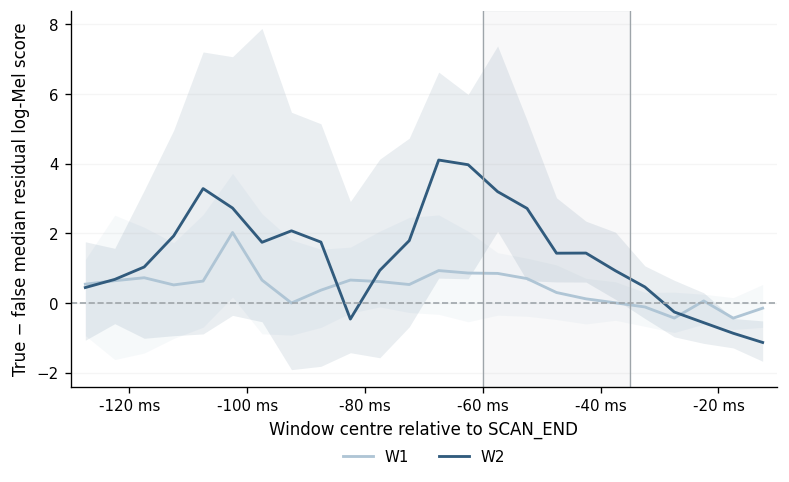

In [49]:
# Figure 1 — historical W1/W2 temporal localisation

fig, ax = plt.subplots(
    figsize=(7.6, 4.6)
)

for summary_data, color, label in [
    (
        summary_w1,
        LIGHT_BLUE,
        "W1",
    ),
    (
        summary_w2,
        DARK_BLUE,
        "W2",
    ),
]:
    ax.plot(
        summary_data[
            "window_centre_ms"
        ],
        summary_data[
            "median_contrast_db"
        ],
        linewidth=1.7,
        color=color,
        label=label,
    )

    ax.fill_between(
        summary_data[
            "window_centre_ms"
        ].to_numpy(),
        summary_data[
            "median_ci_low"
        ].to_numpy(),
        summary_data[
            "median_ci_high"
        ].to_numpy(),
        color=color,
        alpha=0.10,
        linewidth=0,
    )


ax.axvspan(
    LOCKED_START_MS,
    LOCKED_END_MS,
    color=MID_GREY,
    alpha=0.07,
    zorder=0,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    color=MID_GREY,
)

ax.axvline(
    LOCKED_START_MS,
    linewidth=0.8,
    color=MID_GREY,
)

ax.axvline(
    LOCKED_END_MS,
    linewidth=0.8,
    color=MID_GREY,
)

ax.set_xlabel(
    "Window centre relative to SCAN_END"
)

ax.set_ylabel(
    "True − false median residual log-Mel score"
)

ax.set_xlim(
    -130,
    -10,
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x:.0f} ms"
    )
)

ax.grid(
    axis="y",
    alpha=0.12,
)

ax.legend(
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.13,
    ),
)

fig.subplots_adjust(
    bottom=0.20
)

save_figure(
    fig,
    "RQ8_Fig1_temporal_localisation",
)

plt.show()

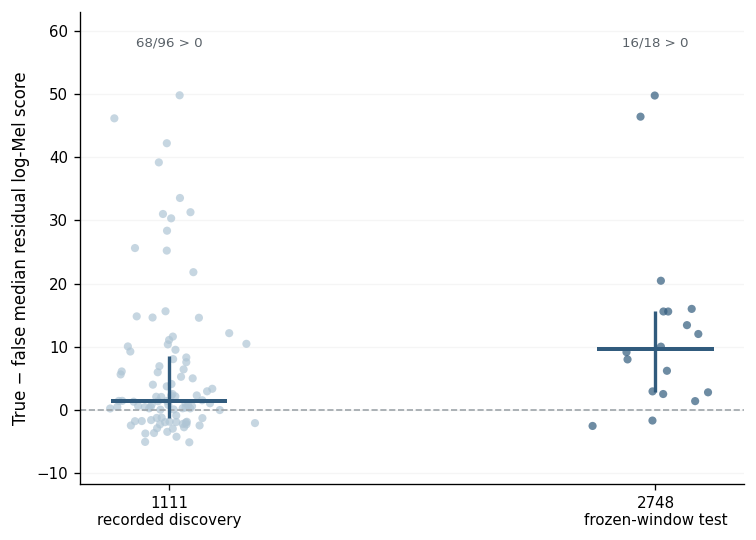

In [50]:
# Figure 2 — W2 locked-window transfer from 1111 to 2748

locked_1111 = scores_w2[
    scores_w2[
        "window_start_ms"
    ]
    == LOCKED_START_MS
].copy()

locked_2748 = scores_2748.copy()

fig, ax = plt.subplots(
    figsize=(6.4, 4.6)
)

rng = np.random.default_rng(
    20260819
)

groups = [
    (
        "1111",
        locked_1111,
        LIGHT_BLUE,
    ),
    (
        "2748",
        locked_2748,
        DARK_BLUE,
    ),
]

all_values = []

for x_pos, (
    password,
    group,
    color,
) in enumerate(
    groups,
    start=1,
):
    values = group[
        "contrast_db"
    ].to_numpy(
        dtype=float
    )

    all_values.extend(
        values.tolist()
    )

    x = rng.normal(
        x_pos,
        0.055,
        size=len(
            values
        ),
    )

    ax.scatter(
        x,
        values,
        s=24,
        color=color,
        edgecolor="none",
        alpha=0.70,
        zorder=2,
    )

    q1, median, q3 = np.quantile(
        values,
        [
            0.25,
            0.50,
            0.75,
        ],
    )

    ax.vlines(
        x_pos,
        q1,
        q3,
        color=DARK_BLUE,
        linewidth=2.0,
        zorder=3,
    )

    ax.hlines(
        median,
        x_pos - 0.12,
        x_pos + 0.12,
        color=DARK_BLUE,
        linewidth=2.4,
        zorder=4,
    )


ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    color=MID_GREY,
)

ax.set_xticks(
    [
        1,
        2,
    ]
)

ax.set_xticklabels([
    "1111\nrecorded discovery",
    "2748\nfrozen-window test",
])

ax.set_ylabel(
    "True − false median residual log-Mel score"
)

y_min = min(
    all_values
)

y_max = max(
    all_values
)

padding = max(
    0.5,
    0.12
    * (
        y_max
        - y_min
    ),
)

ax.set_ylim(
    y_min - padding,
    y_max
    + 2.0 * padding,
)

for x_pos, (
    password,
    group,
    color,
) in enumerate(
    groups,
    start=1,
):
    values = group[
        "contrast_db"
    ].to_numpy(
        dtype=float
    )

    positive = int(
        (
            values
            > 0
        ).sum()
    )

    ax.text(
        x_pos,
        y_max
        + 1.25
        * padding,
        (
            f"{positive}/{len(values)} > 0"
        ),
        ha="center",
        va="center",
        fontsize=8,
        color=DARK_GREY,
    )

ax.grid(
    axis="y",
    alpha=0.12,
)

fig.tight_layout()

save_figure(
    fig,
    "RQ8_Fig2_W2_locked_window_transfer",
)

plt.show()

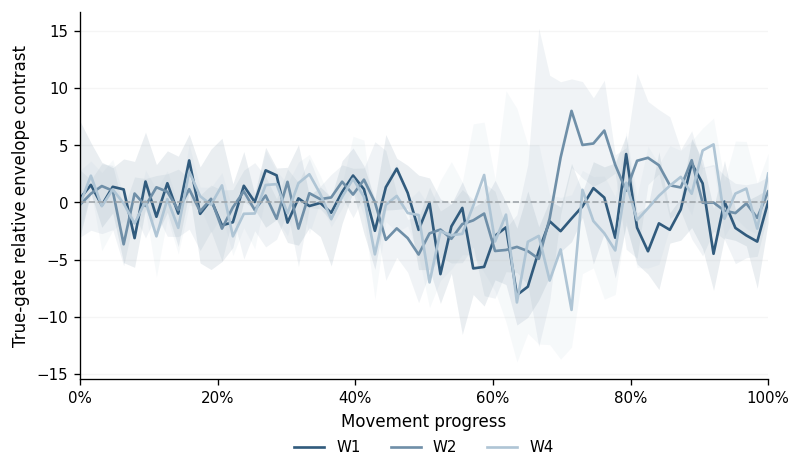

In [51]:
# Figure 3 — independent controlled cross-wheel temporal evidence

fig, ax = plt.subplots(
    figsize=(7.4, 4.5)
)

for wheel, color in [
    (
        1,
        DARK_BLUE,
    ),
    (
        2,
        MID_BLUE,
    ),
    (
        4,
        LIGHT_BLUE,
    ),
]:
    group = rq1_temporal_summary[
        rq1_temporal_summary[
            "wheel"
        ]
        == wheel
    ]

    ax.plot(
        group[
            "movement_progress_pct"
        ],
        group[
            "median"
        ],
        linewidth=1.6,
        color=color,
        label=f"W{wheel}",
    )

    ax.fill_between(
        group[
            "movement_progress_pct"
        ].to_numpy(),
        group[
            "q25"
        ].to_numpy(),
        group[
            "q75"
        ].to_numpy(),
        color=color,
        alpha=0.10,
        linewidth=0,
    )


ax.axhline(
    0,
    color=MID_GREY,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "Movement progress"
)

ax.set_ylabel(
    "True-gate relative envelope contrast"
)

ax.set_xlim(
    0,
    100,
)

ax.set_xticks(
    np.arange(
        0,
        101,
        20,
    )
)

ax.set_xticklabels([
    f"{x}%"
    for x in np.arange(
        0,
        101,
        20,
    )
])

ax.grid(
    axis="y",
    alpha=0.12,
)

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.13,
    ),
)

fig.subplots_adjust(
    bottom=0.20
)

save_figure(
    fig,
    "RQ8_Fig3_controlled_crosswheel_timing",
)

plt.show()

## 9. Result record

In [52]:
# Final result record — conclusions are derived from the fresh reconstruction.

w1_best = (
    summary_w1
    .sort_values(
        ["p_holm", "p_raw"]
    )
    .iloc[0]
)

w2_best = (
    summary_w2
    .sort_values(
        ["p_holm", "p_raw"]
    )
    .iloc[0]
)

w2_sig = (
    summary_w2[
        (summary_w2["p_holm"] < 0.05)
        & (summary_w2["median_contrast_db"] > 0)
    ]
    .sort_values("window_start_ms")
)

segments = []
current_segment = []

for _, row in w2_sig.iterrows():
    row_dict = row.to_dict()

    if (
        not current_segment
        or abs(
            row_dict["window_start_ms"]
            - current_segment[-1]["window_start_ms"]
            - STRIDE_MS
        ) < 1e-9
    ):
        current_segment.append(row_dict)
    else:
        segments.append(current_segment)
        current_segment = [row_dict]

if current_segment:
    segments.append(current_segment)

best_segment = next(
    segment
    for segment in segments
    if any(
        abs(
            row["window_start_ms"]
            - float(w2_best["window_start_ms"])
        ) < 1e-9
        for row in segment
    )
)

broad_start_ms = float(
    best_segment[0]["window_start_ms"]
)

broad_end_ms = float(
    best_segment[-1]["window_end_ms"]
)


conclusion = {
    "research_question": (
        "Where within one one-digit movement does the true-gate acoustic difference occur?"
    ),
    "historical_frozen_W2_window": {
        "start_ms_from_scan_end": LOCKED_START_MS,
        "end_ms_from_scan_end": LOCKED_END_MS,
        "role": (
            "Pre-specified sub-window used for the cross-password confirmation."
        ),
    },
    "fresh_reconstruction": {
        "W1_1111_best_holm_window": {
            "start_ms": float(
                w1_best["window_start_ms"]
            ),
            "end_ms": float(
                w1_best["window_end_ms"]
            ),
            "median_contrast_db": float(
                w1_best["median_contrast_db"]
            ),
            "positive_rate": float(
                w1_best["positive_rate"]
            ),
            "top1": float(
                w1_best["top1"]
            ),
            "mean_true_rank": float(
                w1_best["mean_true_rank"]
            ),
            "p_holm": float(
                w1_best["p_holm"]
            ),
        },
        "W2_1111_best_holm_window": {
            "start_ms": float(
                w2_best["window_start_ms"]
            ),
            "end_ms": float(
                w2_best["window_end_ms"]
            ),
            "median_contrast_db": float(
                w2_best["median_contrast_db"]
            ),
            "positive_rate": float(
                w2_best["positive_rate"]
            ),
            "top1": float(
                w2_best["top1"]
            ),
            "mean_true_rank": float(
                w2_best["mean_true_rank"]
            ),
            "p_holm": float(
                w2_best["p_holm"]
            ),
        },
        "W2_1111_broad_significant_region": {
            "start_ms": broad_start_ms,
            "end_ms": broad_end_ms,
            "definition": (
                "Contiguous late-movement windows around the strongest W2 peak "
                "with positive median contrast and Holm-corrected p < 0.05."
            ),
        },
        "W1_1111_locked": locked_w1_1111,
        "W2_1111_locked": locked_w2_1111,
        "W2_2748_locked": locked_w2_2748,
    },
    "recorded_historical_evidence": {
        "W2_1111": (
            "Historical localisation selected SCAN_END -60 to -35 ms as a useful W2 sub-window."
        ),
        "W2_2748": (
            "The same frozen timing was subsequently tested on password 2748 without retuning."
        ),
        "W3_W4": (
            "Exploratory localisation suggested wheel-dependent timing and is retained as supporting history."
        ),
    },
    "main_v7_model_selection": {
        "full_window": (
            "SCAN_START -20 ms to SCAN_END +100 ms"
        ),
        "dedicated_end_window_contribution": 0.0,
        "final_choice": (
            "Use the full movement; remove the dedicated end-window branch."
        ),
    },
    "interpretation": (
        "The fresh reconstruction supports temporal localisation, but not a single universal "
        "end window. W2 shows a broad late-movement release-like region around the final part "
        "of the movement; its strongest reconstructed 25 ms window can occur earlier than the "
        "historical -60 to -35 ms slice, while the historical frozen slice still lies inside "
        "the broader late-movement effect and transfers strongly to password 2748 without "
        "temporal retuning. W1 also contains statistically detectable temporal structure, "
        "but its strongest windows occur at different times and its performance at the W2 "
        "frozen window is weak. Temporal localisation is therefore wheel-dependent in timing, "
        "strength and ranking utility."
    ),
    "limitation": (
        "The sliding-window residual log-Mel score is a diagnostic localisation statistic "
        "rather than the final MAIN classifier. The W2 historical window was originally "
        "discovered on 1111, so 2748 is the cleaner confirmation because its timing was "
        "frozen in advance. Multiple significant W1 windows mean that 'no W1 temporal cue' "
        "would be too strong; the defensible claim is that W1 does not share the same robust "
        "W2 frozen-window pattern. W3/W4 evidence remains exploratory."
    ),
    "decision": (
        "Treat the local release-like event as physical supporting evidence, not as a universal "
        "feature-engineering rule. Preserve the full movement for the final true-gate model, "
        "because useful timing is wheel-dependent and the dedicated MAIN v7 end-window branch "
        "was selected at 0% contribution."
    ),
    "main_figure_policy": {
        "main_figures": [
            "RQ8_Fig1_temporal_localisation",
            "RQ8_Fig2_W2_locked_window_transfer",
        ],
        "supporting_figure": (
            "RQ8_Fig3_controlled_crosswheel_timing"
        ),
    },
    "next_step": (
        "RQ9 tests whether the local release-like structure can be made universal across wheels."
    ),
}


with open(
    RESULT_DIR
    / "RQ8_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        conclusion,
        f,
        indent=2,
    )


run_info = {
    "notebook": (
        "08_RQ8_Temporal_Localisation.ipynb"
    ),
    "primary_raw_sources": [
        "digit_W1_data",
        "digit_W2_data",
        "code_2748_test_data",
    ],
    "primary_channel": (
        "target/contact channel (first audio channel)"
    ),
    "alignment": "SCAN_END",
    "sliding_window_ms": WINDOW_MS,
    "stride_ms": STRIDE_MS,
    "lookback_ms": LOOKBACK_MS,
    "locked_W2_window_ms": [
        LOCKED_START_MS,
        LOCKED_END_MS,
    ],
    "spectral_representation": {
        "mel_bands": N_MELS,
        "fmin_hz": FMIN_HZ,
        "fmax_hz": FMAX_HZ,
        "n_fft": N_FFT,
        "score": (
            "mean candidate log-Mel residual after per-Mel median subtraction across the 10 candidates"
        ),
    },
    "discovery_statistics": (
        "One-sided scan-level Wilcoxon contrast > 0; Holm correction across 24 temporal windows."
    ),
    "confirmation_statistics": (
        "One-sided scan-level Wilcoxon at the single frozen W2 window; no temporal retuning on 2748."
    ),
    "supporting_dataset": (
        "RQ1 loaded 3517 W1/W2/W4 CCW temporal-envelope contrast"
    ),
}


with open(
    RESULT_DIR
    / "RQ8_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )


print(
    json.dumps(
        conclusion,
        indent=2,
    )
)

print(
    "\nSaved outputs:"
)

for path in sorted(
    RESULT_DIR.glob(
        "RQ8_*"
    )
):
    print(
        " -",
        path.name,
    )

{
  "research_question": "Where within one one-digit movement does the true-gate acoustic difference occur?",
  "historical_frozen_W2_window": {
    "start_ms_from_scan_end": -60.0,
    "end_ms_from_scan_end": -35.0,
    "role": "Pre-specified sub-window used for the cross-password confirmation."
  },
  "fresh_reconstruction": {
    "W1_1111_best_holm_window": {
      "start_ms": -75.0,
      "end_ms": -50.0,
      "median_contrast_db": 0.8640201130861406,
      "positive_rate": 0.5595238095238095,
      "top1": 0.16666666666666666,
      "mean_true_rank": 5.011904761904762,
      "p_holm": 0.01562613426198604
    },
    "W2_1111_best_holm_window": {
      "start_ms": -70.0,
      "end_ms": -45.0,
      "median_contrast_db": 3.2006889810576324,
      "positive_rate": 0.65625,
      "top1": 0.16666666666666666,
      "mean_true_rank": 4.427083333333333,
      "p_holm": 8.980824109428782e-07
    },
    "W2_1111_broad_significant_region": {
      "start_ms": -85.0,
      "end_ms": -25.0,
